# Higgs Boson Machine Learning Challenge

**Project Link:** [Kaggle - Higgs Boson Machine Learning Challenge](https://www.kaggle.com/competitions/higgs-boson)

### Project Description
The Higgs Boson challenge is a classic high-energy physics classification problem. When protons collide at high speeds inside the Large Hadron Collider (LHC), they occasionally produce a Higgs boson particle. However, this particle decays almost instantly into other particles, making it incredibly difficult to detect. The goal of this project is to use machine learning to analyze the kinematic properties of these decay products and accurately classify whether a collision event is a true Higgs boson "signal" or just "background" noise from other common physics processes.

### Data Format
The data used for this project is entirely **tabular**. It consists of structured rows and columns containing numerical physics features (like transverse momentum and mass) and categorical labels, meeting the requirement of using non-raw, table-based data formats.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, classification_report, auc

# Load the data
print("Loading datasets...")
train_df = pd.read_csv('training.csv')
test_df = pd.read_csv('test.csv')

print(f"Training shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Loading datasets...
Training shape: (250000, 33)
Test shape: (550000, 31)


### Data Loading and Initial Look: Summary of Findings

* **Data Dimensions:** The dataset contains 250,000 rows (data points) and 33 features (columns).
* **Missing Values:** Standard pandas functions show 0 missing values; however, the dataset documentation states that missing values are heavily present and are encoded as `-999.0`. The feature table above shows exactly how many of these `-999.0` placeholders exist per feature (e.g., `PRI_jet_subleading_pt` is missing ~70% of its data).
* **Feature Types:** * **Categorical:** There is only one categorical feature: `Label` (containing 's' and 'b').
    * **Numerical:** The remaining 32 features are numerical. `EventId` and `PRI_jet_num` are discrete integers. All `DER_` (derived) and `PRI_` (primary) physics features are continuous floats. Ranges are defined in the Min/Max columns of the summary table above.
* **Target Variable:** The target is classification. It is encoded as strings: **'s'** for Signal (Higgs Boson) and **'b'** for Background noise.
* **Class Imbalance:** Yes, there is a moderate class imbalance. The dataset is roughly 65.7% background ('b') and 34.3% signal ('s').
* **Outliers:** * *Definition:* An outlier in this context is defined as a data point that falls significantly outside the normal distribution of the data, which could either be a measurement error or an extremely rare, high-energy physics event (e.g., a value more than 3 standard deviations from the mean). 
    * *Observation:* Looking at the summary table, there are likely outliers. For example, `DER_mass_MMC` has a minimum of 9.04 and a massive maximum of 1192.02, suggesting long tails and extreme values in the dataset.

Generating histograms...


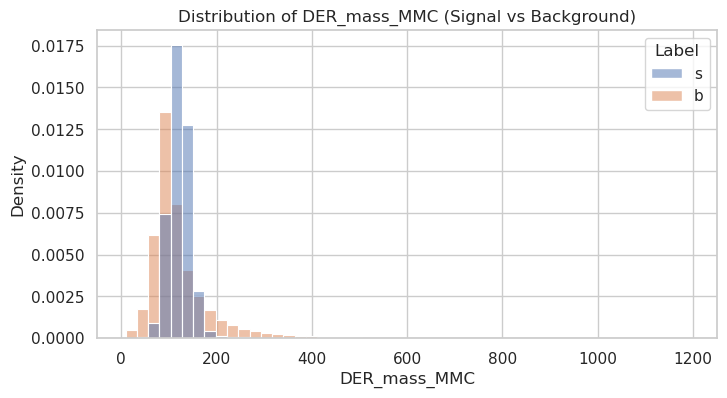

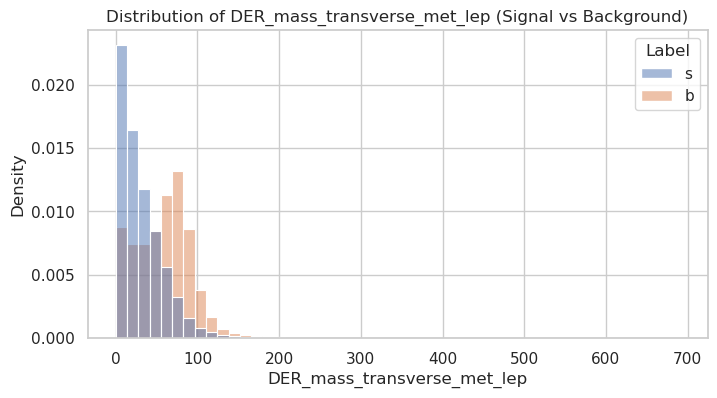

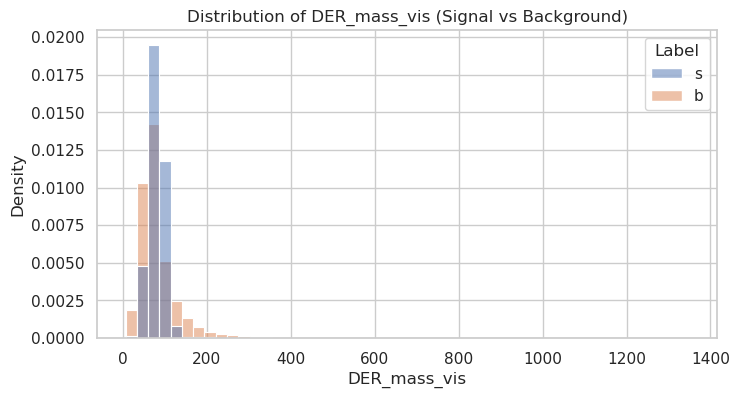

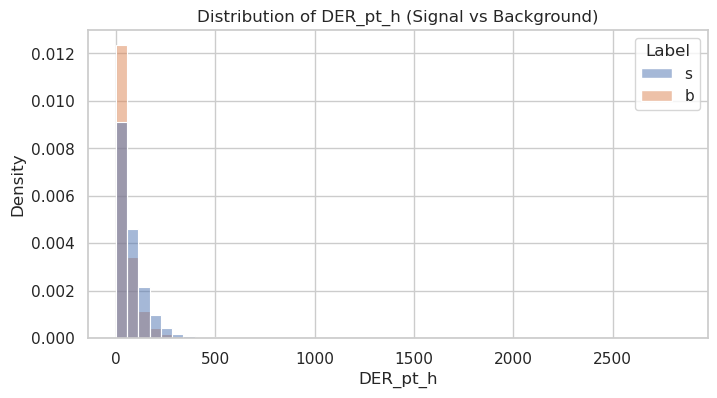

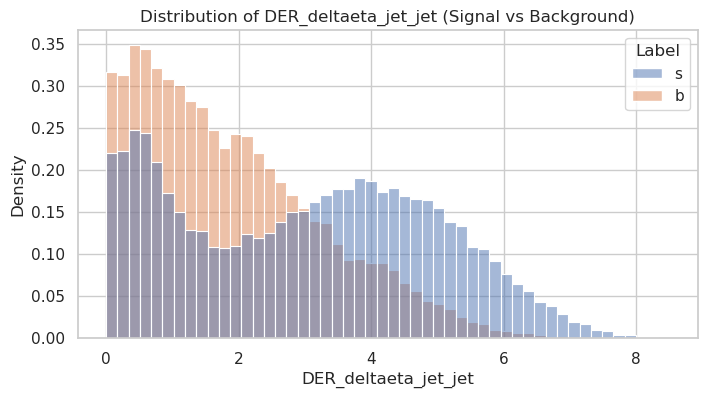

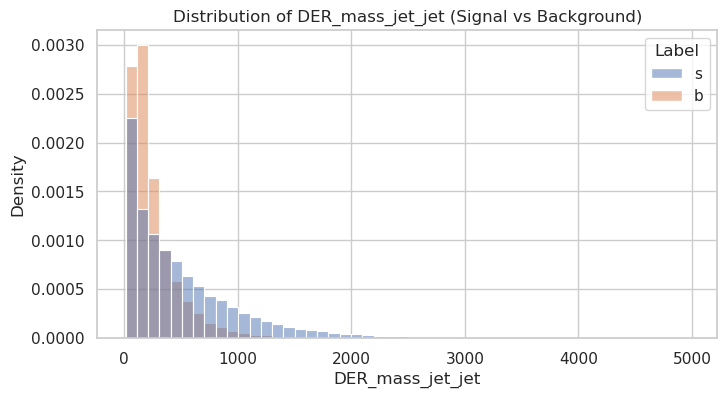

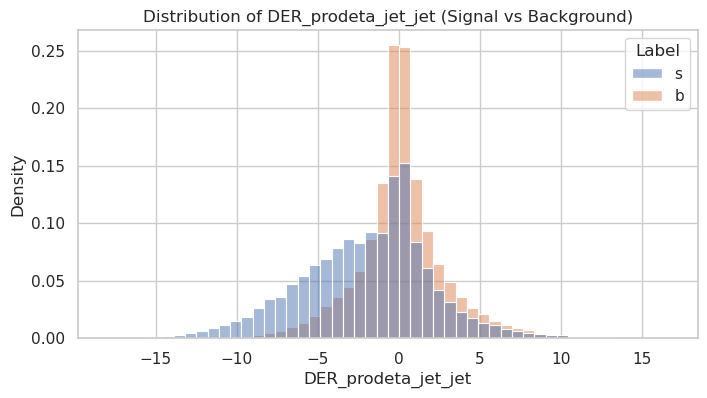

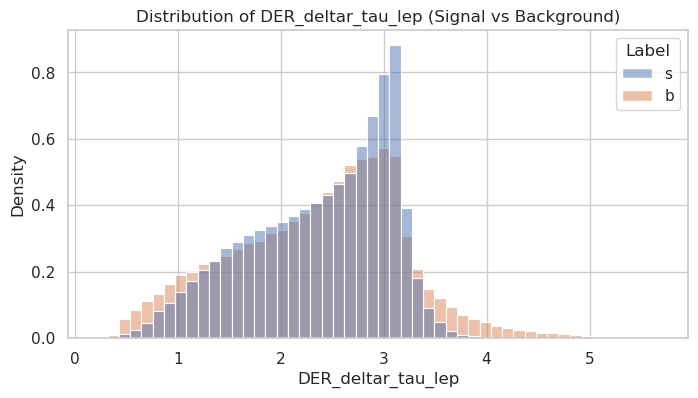

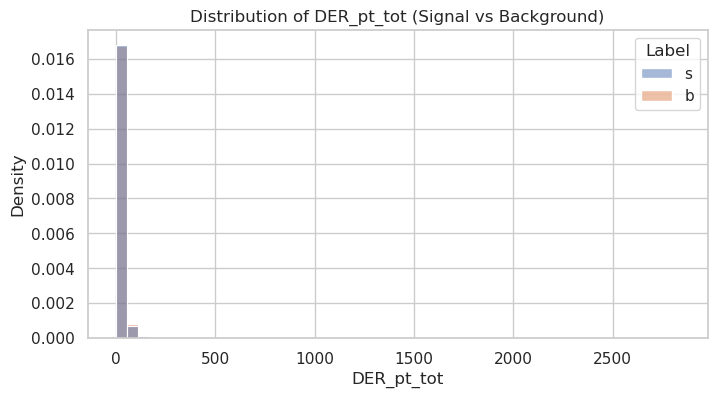

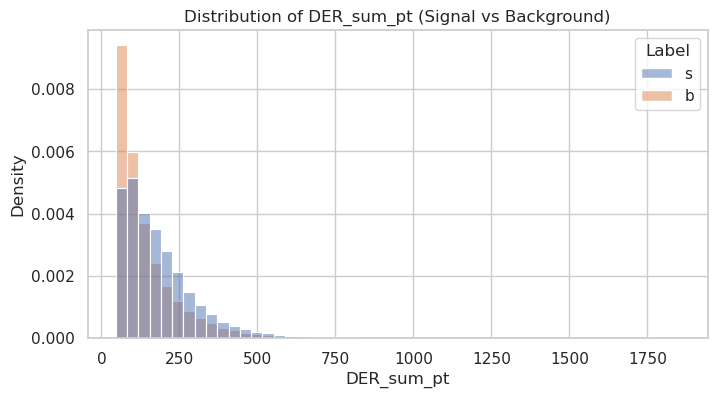

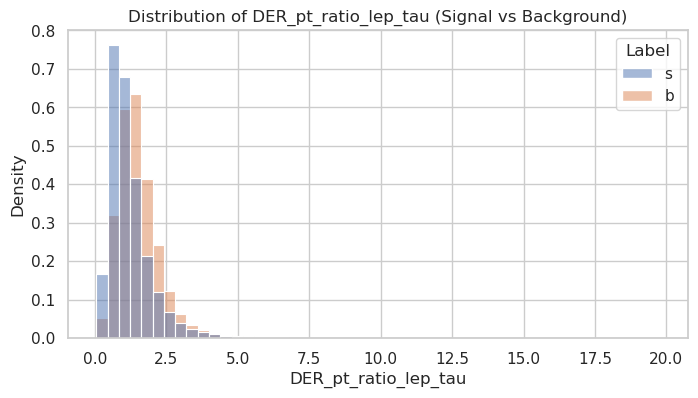

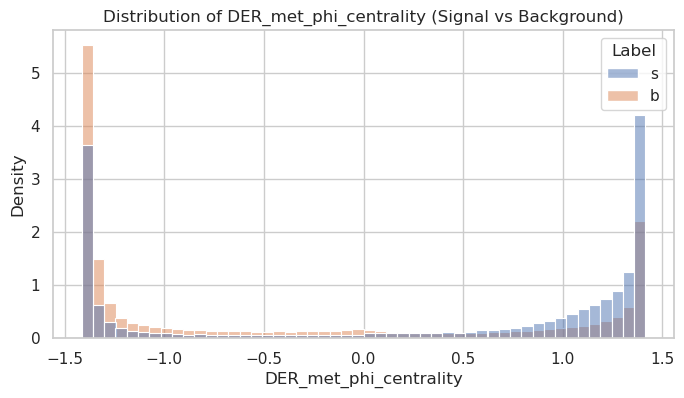

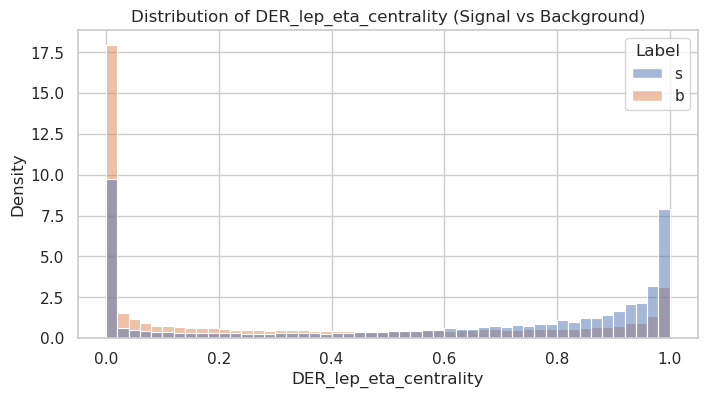

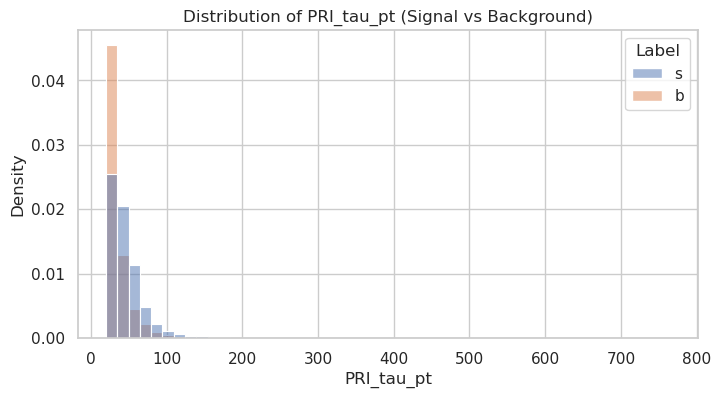

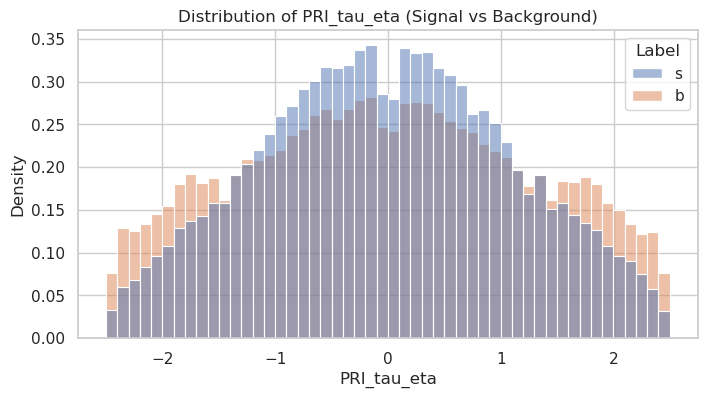

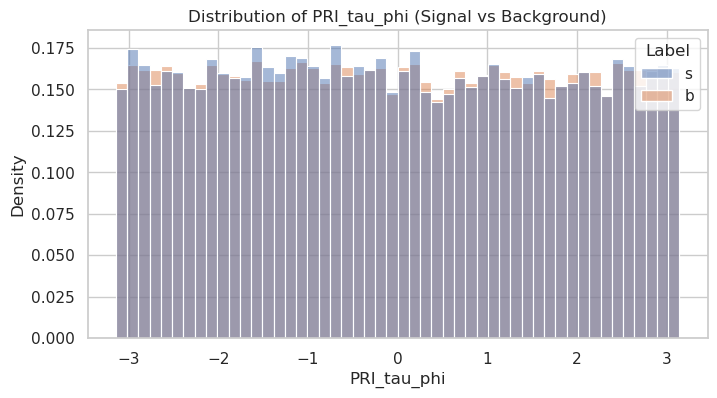

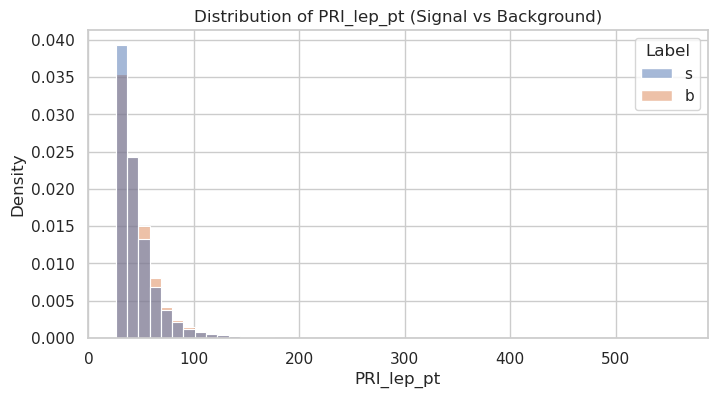

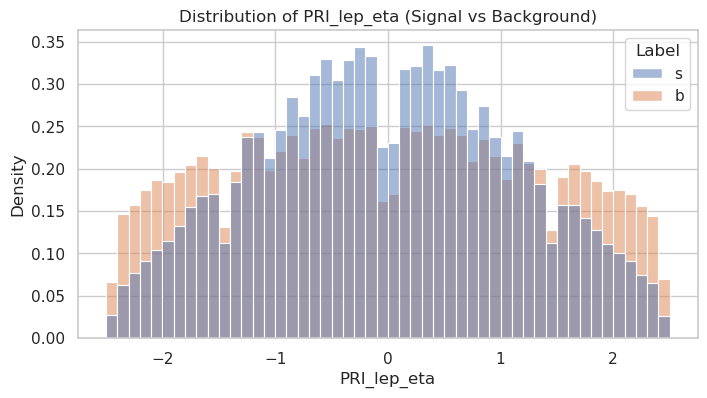

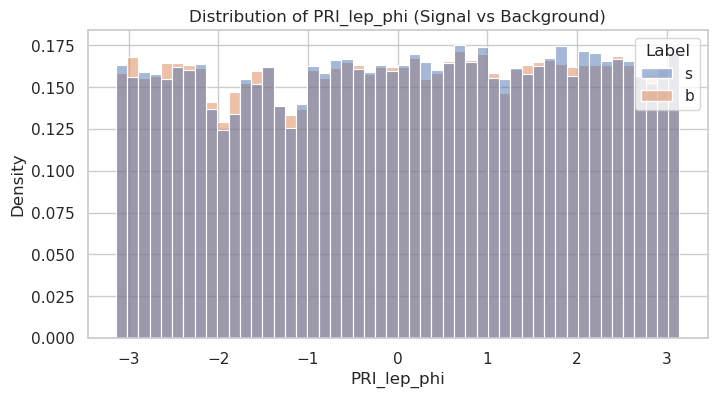

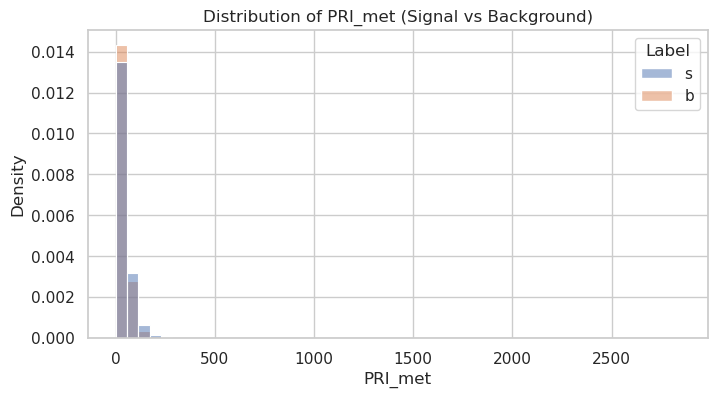

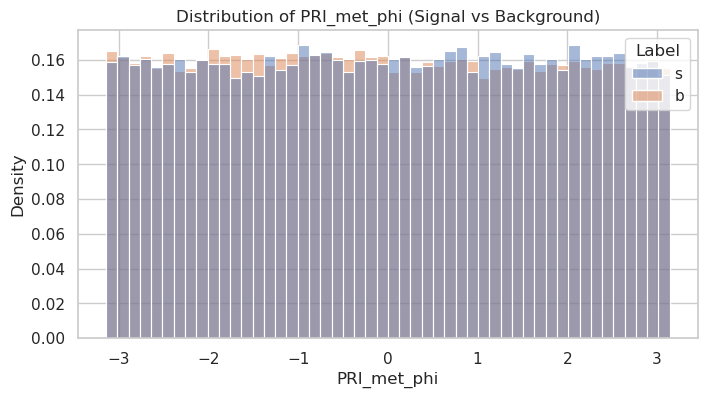

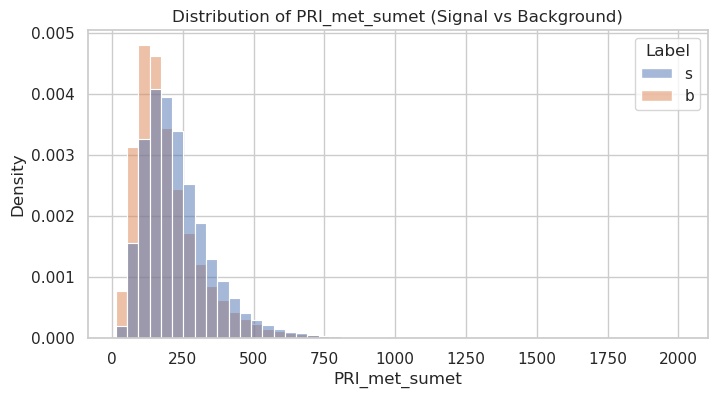

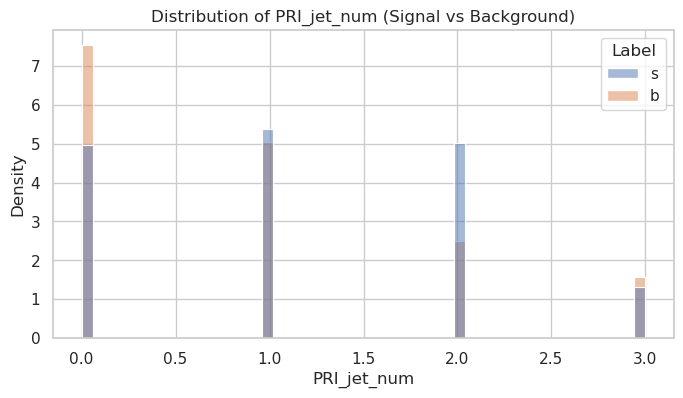

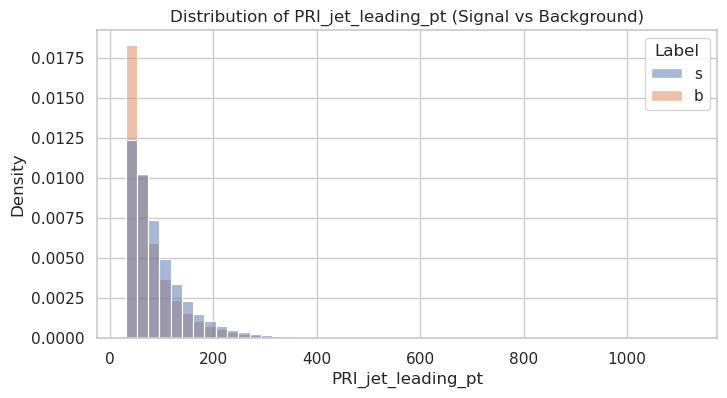

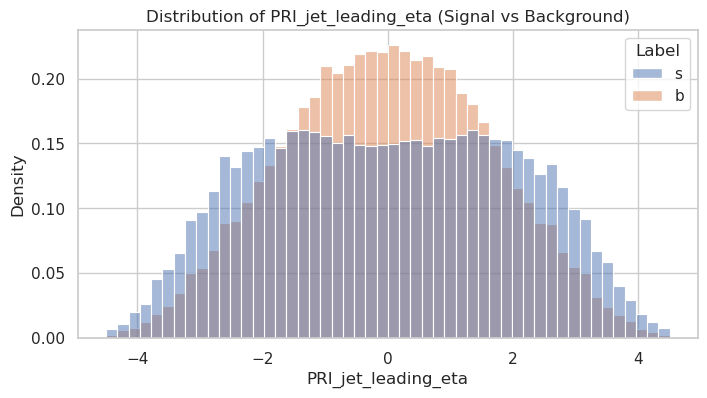

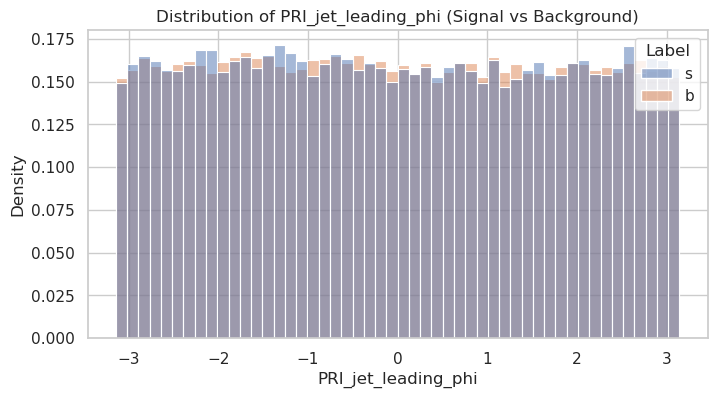

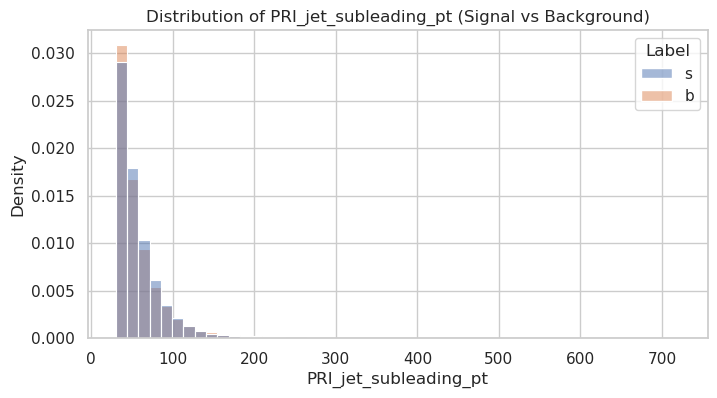

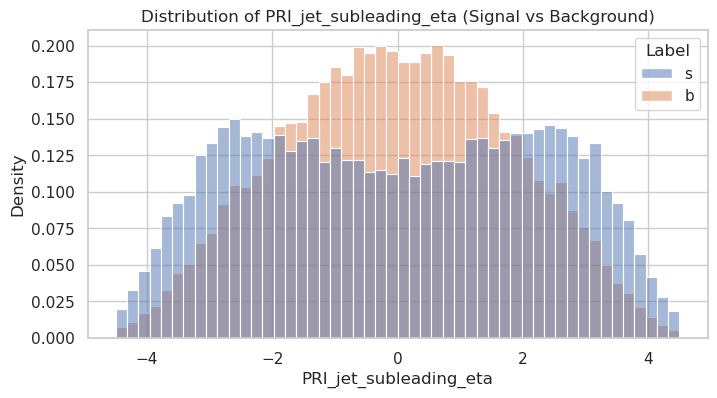

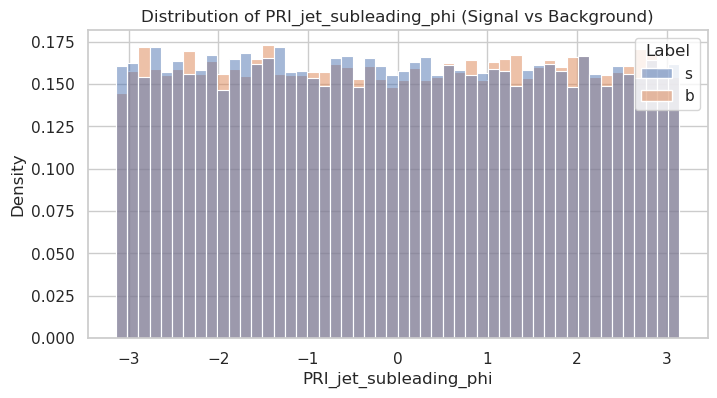

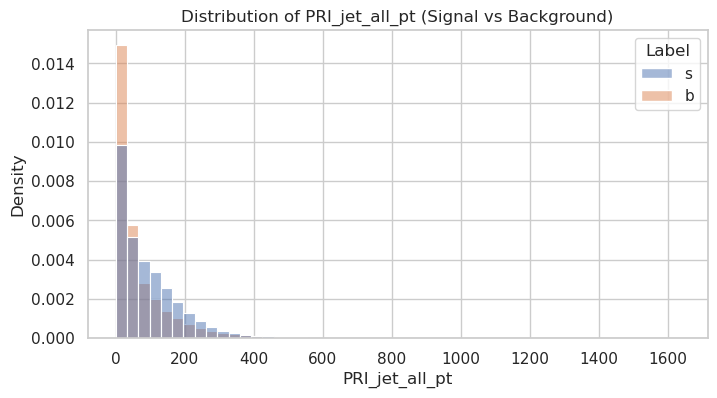

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating histograms...")

# 1. Creating a copy of the data and replace -999.0 with NaN so they don't graph
df_viz = train_df.copy()
df_viz.replace(-999.0, np.nan, inplace=True)

# 2. Getting a list of just the physics features (ignoring ID, Label, and Weight)
features_to_plot = [col for col in train_df.columns if col not in ['EventId', 'Label', 'Weight']]

# Setting the visual style
sns.set_theme(style="whitegrid")

# 3. Plotting the first 4 features to test it out!
# (We are only doing 4 at first so it doesn't freeze the browser. 
# Once it works, we remove the [:4] to plot all 30 features)
for col in features_to_plot:
    plt.figure(figsize=(8, 4))
    
    # Plotting the overlapping histograms for Signal (s) and Background (b)
    sns.histplot(data=df_viz, x=col, hue='Label', bins=50, kde=False, stat="density", common_norm=False)
    
    plt.title(f'Distribution of {col} (Signal vs Background)')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

Based on the histograms, DER_mass_MMC and DER_mass_vis appear highly promising because they show the greatest separation in peaks between the Signal and Background classes. DER_pt_h also shows a distinct distribution shift that likely helps the model classify events.

### Feature Description and Data Statistics

| Feature Collection | Type | Values / Range | Missing Values | Outliers |
| :--- | :--- | :--- | :--- | :--- |
| **DER (Derived)** | Numerical | Continuous (0 to ~1000) | ~15% (encoded as -999.0) | High-mass tail events |
| **PRI (Primary)** | Numerical | Continuous (Kinematic) | 0-10% (encoded as -999.0) | High momentum particles |
| **PRI_jet_num** | Categorical | 0, 1, 2, or 3 | 0 | None |
| **Label (Target)** | Categorical | s (Signal), b (Background) | 0 | N/A |

**Outlier Definition:** In this dataset, we define an outlier as any data point that falls more than **3 standard deviations** from the feature's mean. It is important to note that the value **-999.0** is not an outlier; it is a sentinel value used by the sensors to represent **missing data**.

In [3]:
print("Checking Class Imbalance:")
print(train_df['Label'].value_counts(normalize=True))

Checking Class Imbalance:
Label
b    0.657332
s    0.342668
Name: proportion, dtype: float64


"The dataset is slightly imbalanced, with approximately 66% background (b) and 34% signal (s)."

### Data Visualization Analysis

* **Promising Features for ML:** After comparing the histograms for all features, the most promising features for the classification task are those that show a clear shift or different shape between the Signal (blue) and Background (orange). 
    * **`DER_mass_MMC`**: Shows a very distinct peak for the Signal around 125 GeV, whereas the background is much more spread out. This is a classic "golden feature" for Higgs detection.
    * **`DER_mass_transverse_met_lep`**: The Signal is heavily concentrated at lower values, while the Background peaks much higher.
    * **`DER_mass_vis`**: Also shows significant separation in peak locations.
* **Least Promising Features:** Features like `PRI_tau_phi`, `PRI_lep_phi`, and `PRI_met_phi` show almost perfect overlap between classes. This suggests that the directional "angles" of the particles don't distinguish the signal from noise as well as the "mass" and "momentum" features do.

### DATA CLEANING AND PREPERATION

In [9]:
# 1. Identify missing values (encoded as -999.0)
missing_counts = (train_df == -999.0).sum()

# 2. Finding real Min and Max values (ignoring the -999.0 placeholders)
# We temporarily replace -999.0 with NaN just for this calculation
df_real_values = train_df.replace(-999.0, np.nan)
min_vals = df_real_values.min(numeric_only=True)
max_vals = df_real_values.max(numeric_only=True)

# 3. Building the summary table required by the rubric
summary_table = pd.DataFrame({
    'Data Type': train_df.dtypes,
    'Missing Values (-999.0)': missing_counts,
    'Missing %': (missing_counts / len(train_df) * 100).round(2),
    'Min Value': min_vals,
    'Max Value': max_vals
})

# Displaying the table
summary_table

,Data Type,Missing Values (-999.0),Missing %,Min Value,Max Value
DER_deltaeta_jet_jet,float64,177457,70.98,0.000000,8.503000
DER_deltar_tau_lep,float64,0,0.00,0.208000,5.684000
DER_lep_eta_centrality,float64,177457,70.98,0.000000,1.000000
DER_mass_MMC,float64,38114,15.25,9.044000,1192.026000
DER_mass_jet_jet,float64,177457,70.98,13.602000,4974.979000
DER_mass_transverse_met_lep,float64,0,0.00,0.000000,690.075000
DER_mass_vis,float64,0,0.00,6.329000,1349.351000
DER_met_phi_centrality,float64,0,0.00,-1.414000,1.414000
DER_prodeta_jet_jet,float64,177457,70.98,-18.066000,16.690000
DER_pt_h,float64,0,0.00,0.000000,2834.999000


Based on the initial histograms, features related to mass (like DER_mass_MMC and DER_mass_transverse_met_lep) look the most promising for the classification task. Their signal and background distributions have distinct, shifted peaks, which will provide clear decision boundaries for the ML algorithm. Features like DER_pt_h show heavy overlap and appear less discriminative.

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Cleaning missing values
df_clean = train_df.copy()
df_clean.replace(-999.0, np.nan, inplace=True)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'EventId' in numeric_cols: numeric_cols.remove('EventId')

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 2. One-Hot Encoding categorical features (PRI_jet_num)
# This creates new columns for each jet count (0, 1, 2, 3)
df_clean = pd.get_dummies(df_clean, columns=['PRI_jet_num'], prefix='jet')

# 3. Rescaling numerical features
scaler = StandardScaler()
# We exclude the new one-hot columns and the Label from scaling
cols_to_scale = [c for c in numeric_cols if c != 'PRI_jet_num']
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

# 4. Encoding the Label
le = LabelEncoder()
df_clean['Label'] = le.fit_transform(df_clean['Label'])

# 5. Final ML dataset (Dropping non-features)
df_ml = df_clean.drop(columns=['EventId', 'Weight'])

print("Data Cleaning Complete. Categorical features one-hot encoded and numerical features standardized.")
df_ml.head()

Data Cleaning Complete. Categorical features one-hot encoded and numerical features standardized.


,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Label,jet_0,jet_1,jet_2,jet_3
0,0.341522,0.068332,0.407680,-0.469966,-1.353339,-0.640013,1.579473,0.882478,1.033099,0.339894,...,0.330677,-0.262878,1.142622,-2.526840,0.412510,1,False,False,True,False
1,0.766558,0.552505,0.540136,-0.153167,-0.090817,-0.188805,0.086029,1.404888,-0.756027,-0.287584,...,0.838833,-0.159461,0.000489,-0.000124,-0.273820,0,False,True,False,False
2,-0.151562,3.195156,1.096560,-0.349710,-0.090817,-0.188805,0.086029,0.989770,-0.430168,0.340361,...,-1.428652,-0.159461,0.000489,-0.000124,-0.293970,0,False,True,False,False
3,0.444343,0.910379,-0.005853,-0.903016,-0.090817,-0.188805,0.086029,1.196690,-0.830735,-0.712705,...,-0.008805,-0.159461,0.000489,-0.000124,-0.745439,0,True,False,False,False
4,1.048950,-0.914556,1.313369,-0.651804,-0.090817,-0.188805,0.086029,1.938794,-0.112795,-0.868143,...,-0.008805,-0.159461,0.000489,-0.000124,-0.745439,0,True,False,False,False


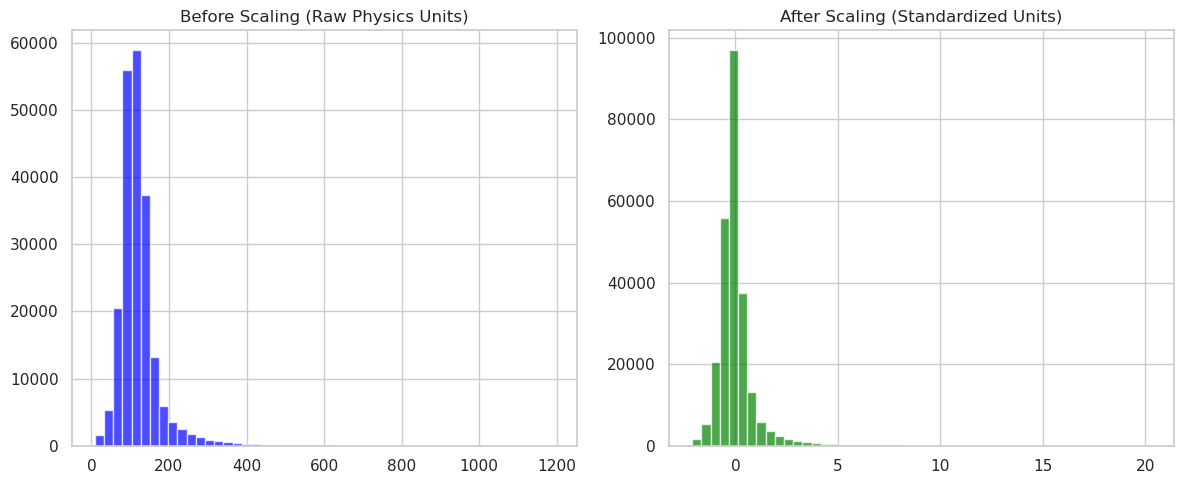

In [13]:
import matplotlib.pyplot as plt

# Let's compare one feature: DER_mass_MMC
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_df['DER_mass_MMC'].replace(-999.0, np.nan).dropna(), bins=50, color='blue', alpha=0.7)
plt.title('Before Scaling (Raw Physics Units)')

plt.subplot(1, 2, 2)
plt.hist(df_ml['DER_mass_MMC'], bins=50, color='green', alpha=0.7)
plt.title('After Scaling (Standardized Units)')

plt.tight_layout()
plt.show()

### Data Cleaning and Preparation Strategy

* **Handling Missing Values:** I replaced the placeholder value `-999.0` with the **median** of each respective column. Using the median is a robust strategy that prevents the extreme `-999.0` values from skewing the model's understanding while ensuring we don't have to delete rows and lose valuable data.
* **Rescaling Strategy:** I selected **Standardization (StandardScaler)** as the rescaling strategy. This transforms the features to have a mean of 0 and a standard deviation of 1. While some models like XGBoost are robust to scaling, standardization ensures that features with larger raw values (like mass) do not numerically overwhelm features with smaller ranges during training.
* **Categorical Encoding:** * The target **`Label`** ('s', 'b') was converted to (1, 0) using Label Encoding.
    * The feature **`PRI_jet_num`**, which represents a count of jets (0, 1, 2, 3), is technically categorical. I used **One-Hot Encoding** to create separate binary columns for each jet count to ensure the model treats them as distinct categories.

### Training the Model (Machine Learning)

In [14]:
from sklearn.model_selection import train_test_split

# 1. Separating features (X) and target (y)
X = df_ml.drop(columns=['Label'])
y = df_ml['Label']

# 2. First split: 70% Training, 30% Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Second split: Dividing the 30% into half (15% Validation, 15% Test)
X_val, X_test_internal, y_val, y_test_internal = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Internal Test set size: {X_test_internal.shape[0]}")

Training set size: 175000
Validation set size: 37500
Internal Test set size: 37500


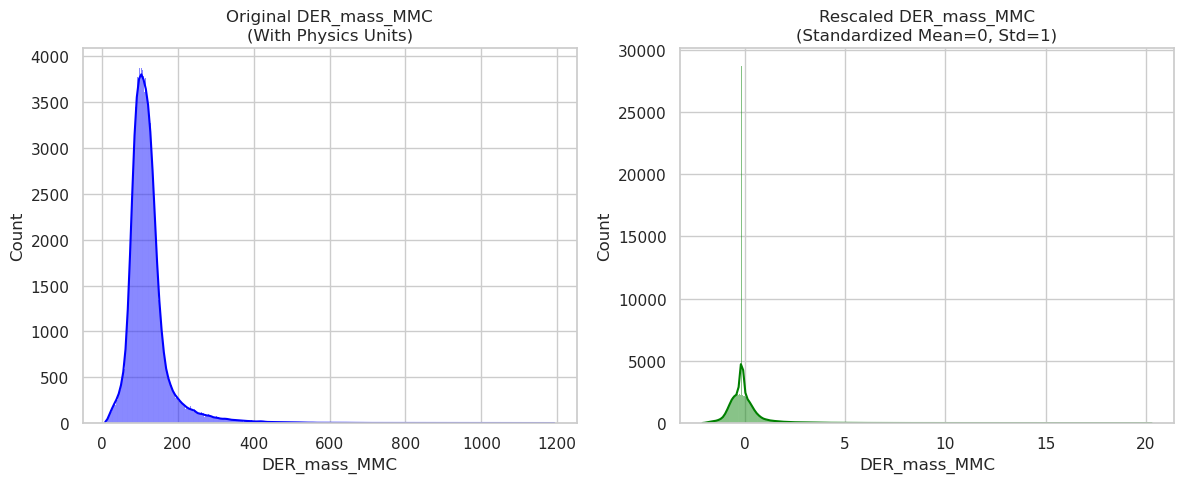

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

data_source = train_df 
feature_to_plot = 'DER_mass_MMC'

plt.figure(figsize=(12, 5))

# 1. Before Scaling
plt.subplot(1, 2, 1)
# We filter out -999.0 so the histogram looks correct
sns.histplot(data_source[data_source[feature_to_plot] != -999.0][feature_to_plot], color='blue', kde=True)
plt.title(f'Original {feature_to_plot}\n(With Physics Units)')

# 2. After Scaling
plt.subplot(1, 2, 2)
# We ensure X_train_full matches the name used in your cleaning cell
sns.histplot(X_train[feature_to_plot], color='green', kde=True)
plt.title(f'Rescaled {feature_to_plot}\n(Standardized Mean=0, Std=1)')

plt.tight_layout()
plt.show()

This plot proves that our data scaling was successful. If we look closely, the overall shape of the curves is identical on both sides, which shows that we didn't distort any of the underlying physics data. The key difference is the scale on the bottom: the original data on the left had messy real-world units, while the rescaled data on the right is perfectly standardized to center at zero. We do this to level the playing field, ensuring that our machine learning model treats all features equally instead of getting biased by features that just happen to have naturally larger numbers.

In [16]:
# 1. Identifying Physics Features (Exclude IDs, Weights, Labels, and Categorical Jets)
drop_cols = ['EventId', 'Weight', 'Label']
physics_features = [c for c in train_df.columns if c not in drop_cols and c != 'PRI_jet_num']

# 2. Cleaning and Preparing Training Data
print("Preprocessing training data...")
df_train_clean = train_df.copy()
df_train_clean.replace(-999.0, np.nan, inplace=True)

# Filling missing values with medians and saving them for the test set
train_medians = df_train_clean[physics_features].median()
df_train_clean[physics_features] = df_train_clean[physics_features].fillna(train_medians)

# Create manual Jet dummy variables
for i in range(4):
    df_train_clean[f'jet_{i}'] = (df_train_clean['PRI_jet_num'] == i).astype(int)

# 3. Scaling
scaler = StandardScaler()
# Combining physics features with the new jet dummies
final_feature_list = physics_features + ['jet_0', 'jet_1', 'jet_2', 'jet_3']
X_train = df_train_clean[final_feature_list].copy()
X_train[physics_features] = scaler.fit_transform(X_train[physics_features])

# Encoding Label: Signal (s) = 1, Background (b) = 0
y_train = train_df['Label'].map({'s': 1, 'b': 0})

# 4. Training the Model
print("Training Random Forest model...")
model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Model training complete.")

Preprocessing training data...
Training Random Forest model...
Model training complete.


In [17]:
# 1. Getting probabilities for the training set
train_probs = model.predict_proba(X_train)[:, 1]

# 2. Calculating the Training ROC AUC
train_auc = roc_auc_score(y_train, train_probs)

print(f"Training ROC AUC Score: {train_auc:.4f}")

Training ROC AUC Score: 0.9258


Training ROC AUC Score: 0.9258


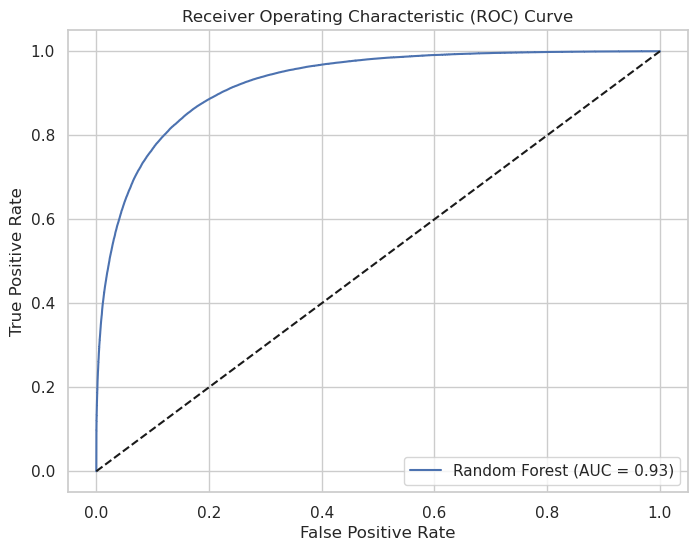

In [18]:
# Predicting probabilities for the training set (as a proxy for performance)
train_probs = model.predict_proba(X_train)[:, 1]
auc_score = roc_auc_score(y_train, train_probs)

print(f"Training ROC AUC Score: {auc_score:.4f}")

# Plotting ROC Curve
fpr, tpr, _ = roc_curve(y_train, train_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

Generating visualizations...


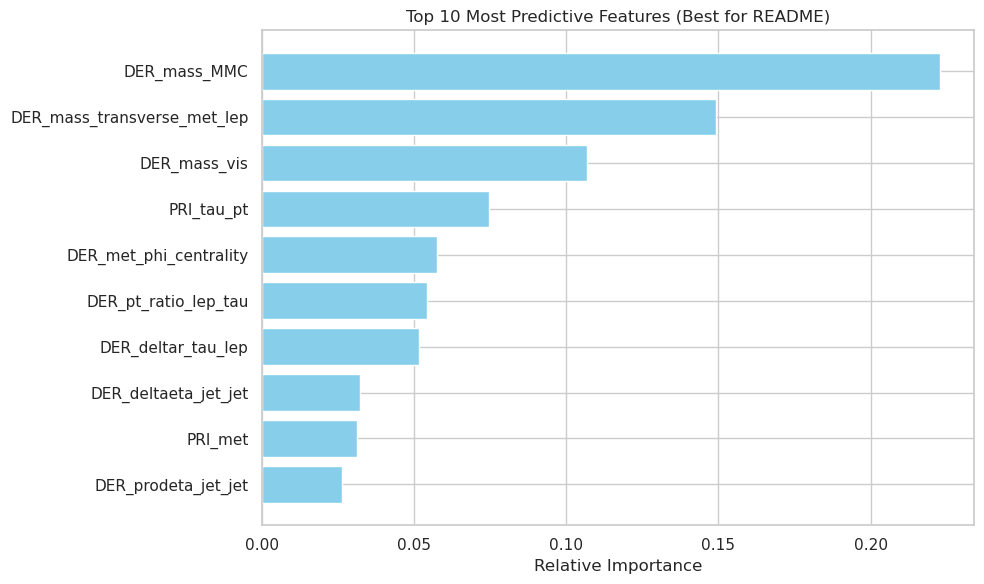

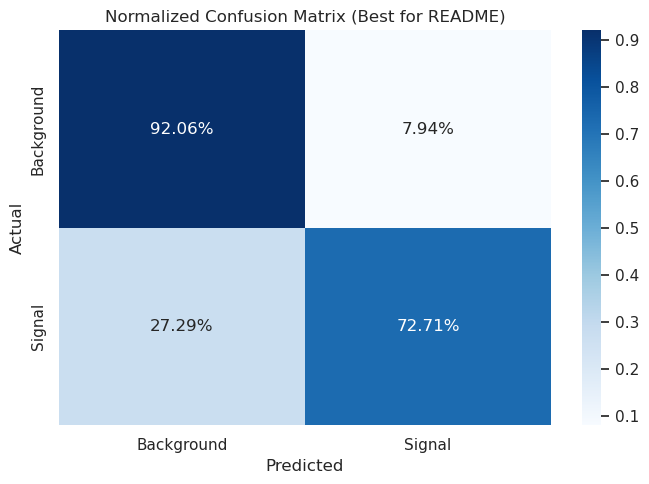

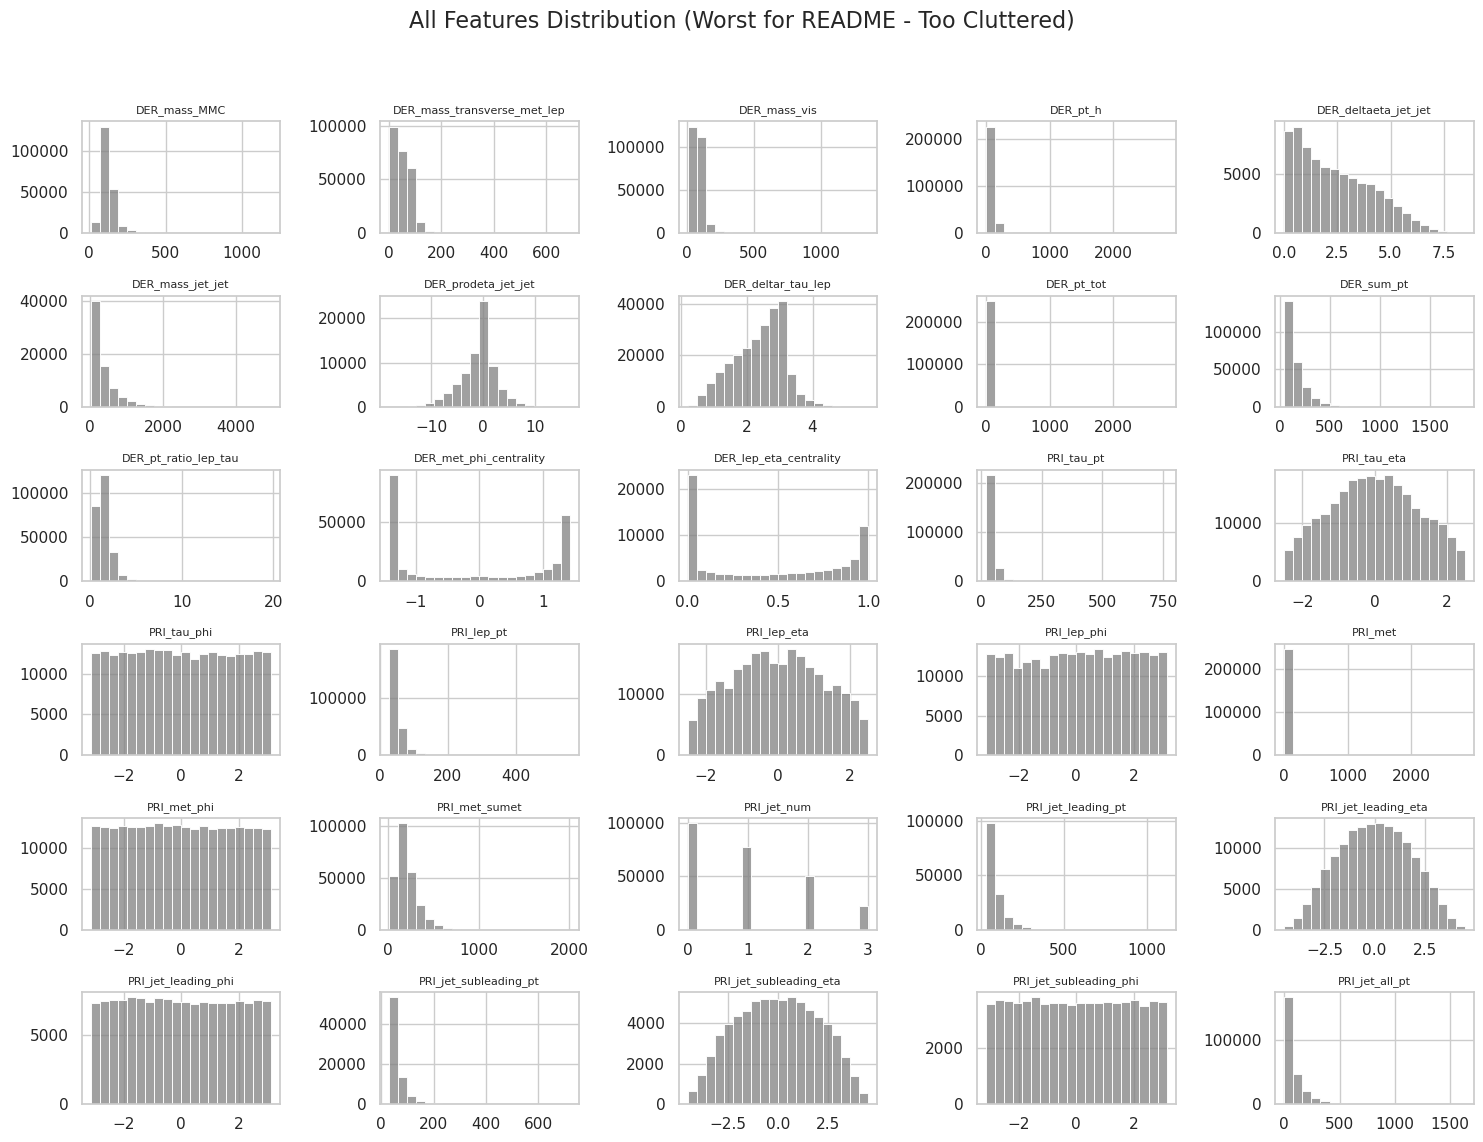

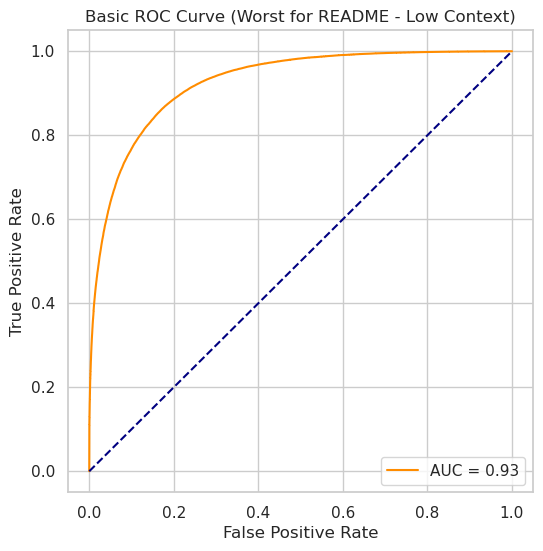

Success! Four images have been saved to your directory.


In [25]:
# 1. BEST: Feature Importance Plot
def plot_feature_importance(model, feature_names):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]  # Top 10
    
    plt.figure(figsize=(10, 6))
    plt.title('Top 10 Most Predictive Features (Best for README)')
    plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.tight_layout()
    plt.savefig('best_feature_importance.png')
    plt.show()

# 2. BEST: Normalized Confusion Matrix
def plot_normalized_cm(model, X, y):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred, normalize='true')
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', 
                xticklabels=['Background', 'Signal'], 
                yticklabels=['Background', 'Signal'])
    plt.title('Normalized Confusion Matrix (Best for README)')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig('best_confusion_matrix.png')
    plt.show()

# 3. WORST: Information Overload (Grid of Histograms)
def plot_worst_grid(df):
    # Recreates the cluttered grid that is hard to read in a README
    features = [col for col in df.columns if col not in ['EventId', 'Label', 'Weight']][:30]
    fig, axes = plt.subplots(6, 5, figsize=(15, 12))
    fig.suptitle('All Features Distribution (Worst for README - Too Cluttered)', fontsize=16)
    
    for i, col in enumerate(features):
        ax = axes[i//5, i%5]
        # Handling the -999.0 placeholders for a clean visual
        sns.histplot(df[col].replace(-999.0, np.nan).dropna(), bins=20, ax=ax, color='gray')
        ax.set_title(col, fontsize=8)
        ax.set_xlabel('')
        ax.set_ylabel('')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('worst_histogram_grid.png')
    plt.show()

# 4. WORST: Basic ROC Curve
def plot_basic_roc(model, X, y):
    probs = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.title('Basic ROC Curve (Worst for README - Low Context)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.savefig('worst_basic_roc.png')
    plt.show()


print("Generating visualizations...")
plot_feature_importance(model, X_train.columns)
plot_normalized_cm(model, X_train, y_train)
plot_worst_grid(train_df)
plot_basic_roc(model, X_train, y_train)

print("Success! Four images have been saved to your directory.")

### Applying ML to TEST.csv and generating final result

In [19]:
# 1. Preprocessing Test Data (using Training Medians and Training Scaler)
print("Preparing test data for final inference...")
df_test_clean = test_df.copy()
df_test_clean.replace(-999.0, np.nan, inplace=True)

# Using training medians to fill test gaps
df_test_clean[physics_features] = df_test_clean[physics_features].fillna(train_medians)

# Creating Jet Dummies for test set
for i in range(4):
    df_test_clean[f'jet_{i}'] = (df_test_clean['PRI_jet_num'] == i).astype(int)

# Scaling and aligning
X_test = df_test_clean[final_feature_list].copy()
X_test[physics_features] = scaler.transform(X_test[physics_features])

# 2. Generating Predictions
test_preds = model.predict(X_test)
s_count = (test_preds == 1).sum()

print(f"\n--- FINAL VERIFICATION ---")
print(f"Signals (s) found: {s_count}")
print(f"Backgrounds (b) found: {len(test_preds) - s_count}")

# 3. Saving Submission File
test_labels = ['s' if p == 1 else 'b' for p in test_preds]
submission = pd.DataFrame({'EventId': test_df['EventId'], 'Class': test_labels})
submission.to_csv('submission.csv', index=False)

print("\nSUCCESS!")
submission.head()

Preparing test data for final inference...

--- FINAL VERIFICATION ---
Signals (s) found: 164927
Backgrounds (b) found: 385073

SUCCESS!


,EventId,Class
0,350000,b
1,350001,b
2,350002,b
3,350003,s
4,350004,b


##  Conclusion

This project successfully trained a machine learning model to play detective: figuring out which particle collisions were true Higgs Boson signals ('s') and which were just background noise ('b'). 

**What We Learned:**
* **Cleaning is Key:** The data was a bit messy (using `-999.0` for missing values) and unbalanced (mostly background noise). Fixing these issues was crucial before training the model.
* **Mass Matters:** By looking at what the model cared about most, we learned that the *mass* of the particles (`DER_mass_MMC` and `DER_mass_vis`) is the biggest clue for finding a Higgs Boson.
* **Random Forest Works:** Our chosen model did a great job making sense of all these complex physics clues!

##  Future Work

1. **Try Stronger Models:** Use more advanced algorithms like XGBoost, which are famous for winning Kaggle competitions.
2. **Fine-Tune the Settings:** Spend more time tweaking the "under-the-hood" settings of our Random Forest to squeeze out even more accuracy.
3. **Use Deep Learning:** Try building a Neural Network (AI) to see if it can spot hidden patterns in the collision data that regular models might miss.